# Recognising Handwritten Digits on MNIST Dataset using KNN 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Step 1. Data Preparation

In [2]:
df = pd.read_csv('mnist_train.csv')
print(df.shape)

(59999, 785)


In [3]:
print(df.columns)

Index(['5', '0', '0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '0.8',
       ...
       '0.608', '0.609', '0.610', '0.611', '0.612', '0.613', '0.614', '0.615',
       '0.616', '0.617'],
      dtype='object', length=785)


In [4]:
df.head(n=5)

,5,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.608,0.609,0.610,0.611,0.612,0.613,0.614,0.615,0.616,0.617
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
data = df.values
print(data.shape)
print(type(data))

(59999, 785)
<class 'numpy.ndarray'>


In [6]:
X = data[:,1:]
Y = data[:,0]

print(X.shape,Y.shape)

(59999, 784) (59999,)


In [7]:
split = int(0.8*X.shape[0])
print(split)

X_train = X[:split,:]
Y_train = Y[:split]

X_test = X[split:,:]
Y_test = Y[split:]

print(X_train.shape,Y_train.shape)
print(X_test.shape,Y_test.shape)

47999
(47999, 784) (47999,)
(12000, 784) (12000,)


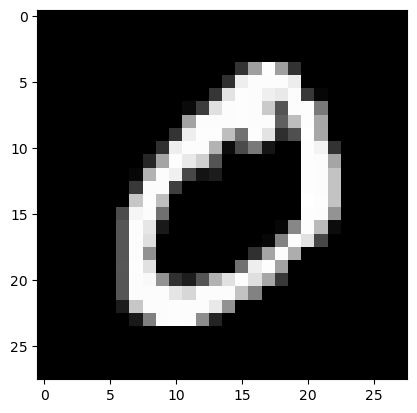

0


In [8]:
#Visualise Some Samples

def drawImg(sample):
    img = sample.reshape((28,28))
    plt.imshow(img,cmap='gray')
    plt.show()
    
drawImg(X_train[0])
print(Y_train[0])
    
    

### Step 2. K-NN

In [32]:
# Can we apply KNN to this data ?

In [9]:
def dist(x1,x2):
    return np.sqrt(sum((x1-x2)**2))

def knn(X,Y,queryPoint,k=5):
    
    vals = []
    m = X.shape[0]
    
    for i in range(m):
        d = dist(queryPoint,X[i])
        vals.append((d,Y[i]))
        
    
    vals = sorted(vals)
    # Nearest/First K points
    vals = vals[:k]
    
    vals = np.array(vals)
    
    #print(vals)
    
    new_vals = np.unique(vals[:,1],return_counts=True)
    #print(new_vals)
    
    index = new_vals[1].argmax()
    pred = new_vals[0][index]
    
    return pred
    
    
    

### Step 3 : Make Predictions 

In [10]:
pred = knn(X_train,Y_train,X_test[1])

print(int(pred))

7


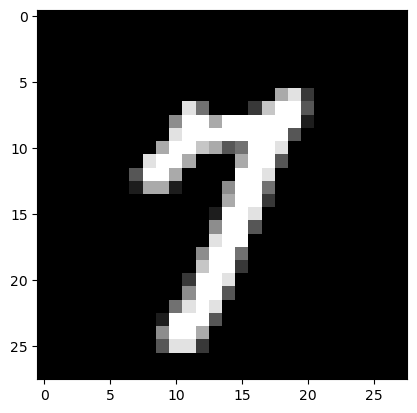

7


In [11]:

drawImg(X_test[1])
print(Y_test[1])

In [12]:
# Write one method which computes accuracy of KNN over the test set !

def accuracy(X_train, Y_train, X_test, Y_test, k=5):
    
    correct = 0
    total = len(X_test)
    
    for i in range(total):
        
        pred = knn(X_train, Y_train, X_test[i], k)
        
        if pred == Y_test[i]:
            correct += 1
    
    acc = correct / total
    return acc

In [15]:
# Accuracy 
acc = accuracy(X_train[:2000], Y_train[:2000], X_test[:200], Y_test[:200], k=5)
print("Accuracy:", acc*100,"%")

Accuracy: 91.0 %
